# **1. Importing Libraries**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

#**2. Loading Datasets**

In [3]:
customer = pd.read_csv ('/content/drive/MyDrive/Project Based Analysis/D6 - 11.04 - Cohort Analysis/Cohort Analysis/Customer.csv')
ecomsales = pd.read_csv ('/content/drive/MyDrive/Project Based Analysis/D6 - 11.04 - Cohort Analysis/Cohort Analysis/EcomSales.csv')
product = pd.read_csv ('/content/drive/MyDrive/Project Based Analysis/D6 - 11.04 - Cohort Analysis/Cohort Analysis/Product.csv')
region = pd.read_csv('/content/drive/MyDrive/Project Based Analysis/D6 - 11.04 - Cohort Analysis/Cohort Analysis/Region.csv')

# **3. Data Exploration and Preprocessing**

In [ ]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17415 entries, 0 to 17414
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      17415 non-null  object
 1   FirstName       17415 non-null  object
 2   LastName        17415 non-null  object
 3   BirthDate       17415 non-null  object
 4   MaritalStatus   17415 non-null  object
 5   Gender          17291 non-null  object
 6   EmailAddress    17415 non-null  object
 7   AnnualIncome    17415 non-null  int64 
 8   EducationLevel  17415 non-null  object
 9   Occupation      17415 non-null  object
 10  HomeOwner       17415 non-null  object
dtypes: int64(1), object(10)
memory usage: 1.5+ MB


In [ ]:
customer['BirthDate'] = customer['BirthDate'].astype('datetime64[ns]')

In [ ]:
ecomsales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   RowID        51290 non-null  int64  
 1   OrderID      51290 non-null  object 
 2   OrderDate    51290 non-null  object 
 3   CustomerID   51290 non-null  object 
 4   Segment      51290 non-null  object 
 5   RegionCode   51290 non-null  object 
 6   ProductCode  51290 non-null  object 
 7   Quantity     51290 non-null  int64  
 8   Sales        51290 non-null  int64  
 9   Discount     51290 non-null  float64
 10  Profit       51290 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 4.3+ MB


In [ ]:
ecomsales['OrderDate']= ecomsales['OrderDate'].astype('datetime64[ns]')

# **4. Cohort Analysis - Overall Retention**

### Task 1: Determine the Acquisition Month for each customer and calculate the retention rate in 2022.

In [ ]:
df_pre_cohort= pd.merge(ecomsales, customer, how='left', on='CustomerID')
df_pre_cohort = df_pre_cohort[['CustomerID', 'OrderDate','Segment','AnnualIncome','Profit','OrderID']]
df_pre_cohort.head()

,CustomerID,OrderDate,Segment,AnnualIncome,Profit,OrderID
0,TH-211151,2020-04-04,Corporate,90000,208.0,IN-2012-TH211151-41003
1,BD-116051,2021-09-01,Consumer,60000,10.0,ID-2013-BD116051-41518
2,TS-212051,2023-06-18,Corporate,60000,8.0,IN-2015-TS212051-42173
3,SU-206651,2022-09-17,Self-Employed,70000,55.6,IN-2014-SU206651-41899
4,GM-144551,2023-08-01,Self-Employed,80000,0.6,IN-2015-GM144551-42217


In [ ]:
df_pre_cohort_first = df_pre_cohort.groupby(by = 'CustomerID', as_index = False).agg(first_order_date = ('OrderDate', 'min') )
df_pre_cohort_first['first_month'] = df_pre_cohort_first['first_order_date'].dt.to_period('M')
df_pre_cohort_first.head()

,CustomerID,first_order_date,first_month
0,AA-10315102,2020-07-03,2020-07
1,AA-10315120,2021-05-16,2021-05
2,AA-10315139,2022-09-19,2022-09
3,AA-103151402,2022-03-04,2022-03
4,AA-103151404,2020-03-30,2020-03


In [ ]:
df_cohort_merge = df_pre_cohort.merge(df_pre_cohort_first, on = 'CustomerID', how ='inner')
df_cohort_merge.head()

,CustomerID,OrderDate,Segment,AnnualIncome,Profit,OrderID,first_order_date,first_month
0,TH-211151,2020-04-04,Corporate,90000,208.0,IN-2012-TH211151-41003,2020-04-04,2020-04
1,BD-116051,2021-09-01,Consumer,60000,10.0,ID-2013-BD116051-41518,2021-09-01,2021-09
2,TS-212051,2023-06-18,Corporate,60000,8.0,IN-2015-TS212051-42173,2023-06-18,2023-06
3,SU-206651,2022-09-17,Self-Employed,70000,55.6,IN-2014-SU206651-41899,2022-09-17,2022-09
4,GM-144551,2023-08-01,Self-Employed,80000,0.6,IN-2015-GM144551-42217,2023-08-01,2023-08


In [ ]:
df_cohort_merge['month_after'] = (df_cohort_merge['OrderDate'].dt.year - df_cohort_merge['first_order_date'].dt.year) * 12 \
                    + (df_cohort_merge['OrderDate'].dt.month - df_cohort_merge['first_order_date'].dt.month)
df_cohort_merge.head()

,CustomerID,OrderDate,Segment,AnnualIncome,Profit,OrderID,first_order_date,first_month,month_after
0,TH-211151,2020-04-04,Corporate,90000,208.0,IN-2012-TH211151-41003,2020-04-04,2020-04,0
1,BD-116051,2021-09-01,Consumer,60000,10.0,ID-2013-BD116051-41518,2021-09-01,2021-09,0
2,TS-212051,2023-06-18,Corporate,60000,8.0,IN-2015-TS212051-42173,2023-06-18,2023-06,0
3,SU-206651,2022-09-17,Self-Employed,70000,55.6,IN-2014-SU206651-41899,2022-09-17,2022-09,0
4,GM-144551,2023-08-01,Self-Employed,80000,0.6,IN-2015-GM144551-42217,2023-08-01,2023-08,0


In [ ]:
df_cohort = df_cohort_merge.pivot_table(index = 'first_month', columns = 'month_after', values = 'CustomerID', aggfunc = 'nunique')
df_cohort = df_cohort[
    (df_cohort.index >= '2022-01') &
    (df_cohort.index <= '2022-12')]
df_cohort = df_cohort.loc[:, 0:11]
df_cohort

month_after,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,252.0,1.0,1.0,4.0,4.0,3.0,4.0,6.0,7.0,4.0,9.0,1.0
2022-02,214.0,4.0,2.0,5.0,1.0,2.0,7.0,5.0,5.0,5.0,3.0,1.0
2022-03,290.0,2.0,5.0,4.0,4.0,9.0,10.0,3.0,7.0,13.0,4.0,3.0
2022-04,258.0,1.0,5.0,2.0,3.0,5.0,3.0,6.0,7.0,1.0,2.0,3.0
2022-05,352.0,7.0,7.0,10.0,8.0,5.0,7.0,13.0,5.0,3.0,5.0,10.0
2022-06,517.0,6.0,17.0,13.0,6.0,6.0,17.0,10.0,6.0,8.0,7.0,12.0
2022-07,292.0,8.0,8.0,4.0,6.0,10.0,3.0,4.0,6.0,2.0,4.0,7.0
2022-08,442.0,13.0,9.0,6.0,9.0,5.0,6.0,10.0,6.0,10.0,5.0,7.0
2022-09,518.0,9.0,15.0,16.0,9.0,7.0,10.0,6.0,18.0,8.0,18.0,11.0


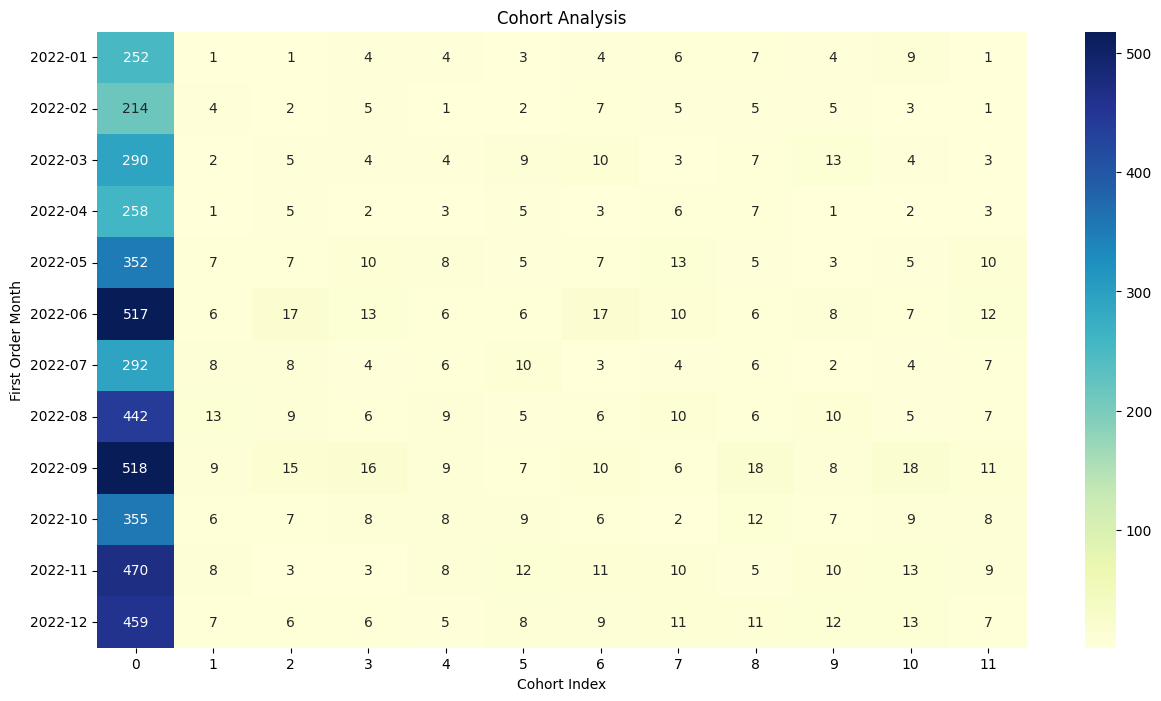

In [ ]:
plt.figure(figsize= (15,8))
sns.heatmap(data = df_cohort
            ,annot=True
            ,cmap='YlGnBu'
            ,fmt = 'g'
            )
plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.title('Cohort Analysis')
plt.show()

In [ ]:
cohort_size_monthly = df_cohort.iloc[:, 0]
retention_matrix_monthly = df_cohort.divide(cohort_size_monthly, axis=0)
retention_matrix_monthly

month_after,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,1.0,0.003968,0.003968,0.015873,0.015873,0.011905,0.015873,0.023810,0.027778,0.015873,0.035714,0.003968
2022-02,1.0,0.018692,0.009346,0.023364,0.004673,0.009346,0.032710,0.023364,0.023364,0.023364,0.014019,0.004673
2022-03,1.0,0.006897,0.017241,0.013793,0.013793,0.031034,0.034483,0.010345,0.024138,0.044828,0.013793,0.010345
2022-04,1.0,0.003876,0.019380,0.007752,0.011628,0.019380,0.011628,0.023256,0.027132,0.003876,0.007752,0.011628
2022-05,1.0,0.019886,0.019886,0.028409,0.022727,0.014205,0.019886,0.036932,0.014205,0.008523,0.014205,0.028409
2022-06,1.0,0.011605,0.032882,0.025145,0.011605,0.011605,0.032882,0.019342,0.011605,0.015474,0.013540,0.023211
2022-07,1.0,0.027397,0.027397,0.013699,0.020548,0.034247,0.010274,0.013699,0.020548,0.006849,0.013699,0.023973
2022-08,1.0,0.029412,0.020362,0.013575,0.020362,0.011312,0.013575,0.022624,0.013575,0.022624,0.011312,0.015837
2022-09,1.0,0.017375,0.028958,0.030888,0.017375,0.013514,0.019305,0.011583,0.034749,0.015444,0.034749,0.021236


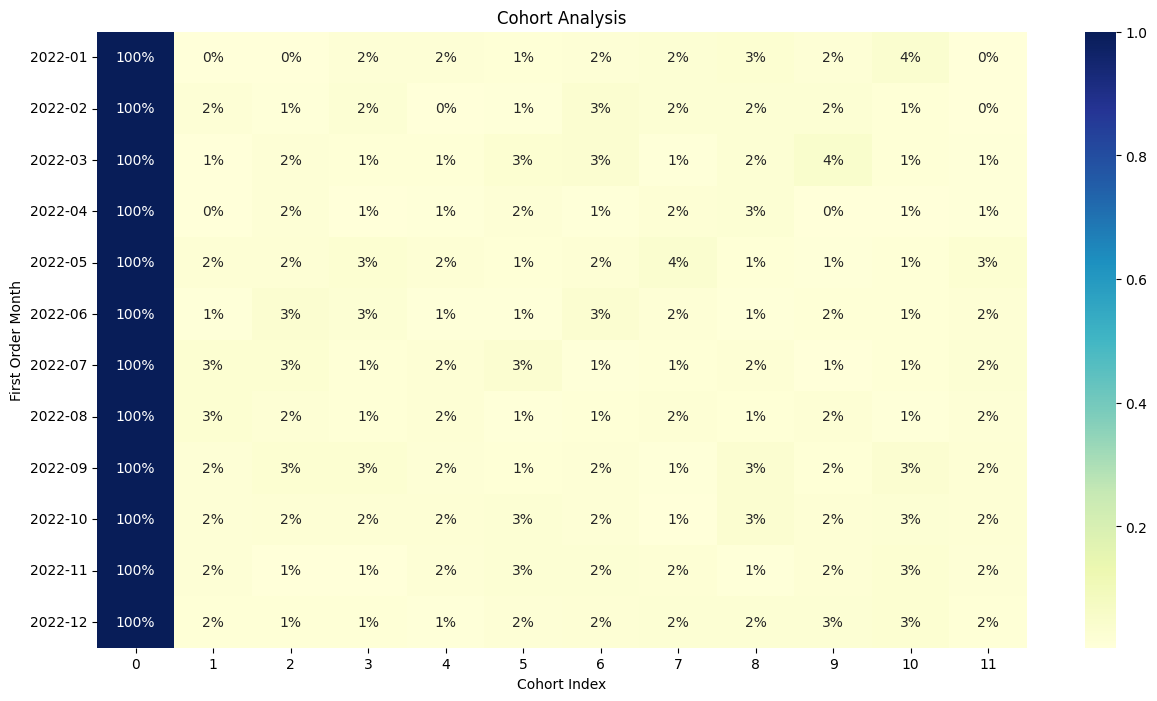

In [ ]:
plt.figure(figsize= (15,8))
sns.heatmap(data = retention_matrix_monthly
            ,annot=True
            ,cmap='YlGnBu'
            ,fmt = '.0%')
plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.title('Cohort Analysis')
plt.show()

**Key Findings:**

Overall retention rate in 2022 is extremely low.

After the first purchase (Month 0 = 100%), the retention rate drops sharply to only 1–3% in almost all subsequent months.
No cohort maintains retention above 4% at any point after Month 0.

**Cohort Comparison:**

There is no clear improvement throughout the year.

Late-2022 cohorts (2022-10, 2022-11, 2022-12) perform similarly poorly to early-2022 cohorts.
Slightly better retention appears in 2022-06 and 2022-09 (occasionally reaching 3–4%), but the difference is minimal.

#**5. Cohort Analysis - Drill-down by Segment**

### Task 2: Drill down by Segment. Compare Retention Rate between Corporate and Consumer groups.

In [ ]:
df_cohort_segment = df_cohort_merge.groupby(['Segment', 'first_month', 'month_after'])['CustomerID'].nunique().reset_index()

corp_counts = df_cohort_segment[df_cohort_segment['Segment'] == 'Corporate'].pivot_table(
    index='first_month',
    columns='month_after',
    values='CustomerID'
)
cons_counts = df_cohort_segment[df_cohort_segment['Segment'] == 'Consumer'].pivot_table(
    index='first_month',
    columns='month_after',
    values='CustomerID'
)

# Filter for 2022 and up to month_after 11
corp_counts = corp_counts.loc['2022-01':'2022-12', :11] # Use :11 to include up to column 11
cons_counts = cons_counts.loc['2022-01':'2022-12', :11]

print("Corporate Cohort Counts:")
display(corp_counts.head(12))

print("\nConsumer Cohort Counts:")
display(cons_counts.head(12))

# Calculate retention rates for Corporate
corp_cohort_size = corp_counts.iloc[:, 0]
corp = corp_counts.divide(corp_cohort_size, axis=0)

# Calculate retention rates for Consumer
cons_cohort_size = cons_counts.iloc[:, 0]
cons = cons_counts.divide(cons_cohort_size, axis=0)

print("\nCorporate Retention Matrix:")
display(corp.head(12))

print("\nConsumer Retention Matrix:")
display(cons.head(12))

Corporate Cohort Counts:


month_after,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,84.0,NaN,1.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,3.0,NaN
2022-02,68.0,2.0,NaN,1.0,1.0,NaN,1.0,3.0,NaN,NaN,1.0,1.0
2022-03,77.0,2.0,1.0,1.0,1.0,2.0,1.0,NaN,2.0,2.0,1.0,NaN
2022-04,74.0,NaN,1.0,1.0,1.0,2.0,NaN,1.0,2.0,NaN,1.0,NaN
2022-05,94.0,4.0,4.0,2.0,5.0,3.0,3.0,5.0,2.0,NaN,2.0,5.0
2022-06,158.0,1.0,9.0,5.0,1.0,1.0,2.0,4.0,2.0,3.0,2.0,5.0
2022-07,94.0,2.0,2.0,2.0,2.0,5.0,1.0,1.0,2.0,1.0,2.0,3.0
2022-08,138.0,4.0,4.0,3.0,3.0,3.0,1.0,3.0,1.0,4.0,2.0,3.0
2022-09,162.0,NaN,NaN,3.0,2.0,2.0,2.0,1.0,3.0,2.0,4.0,4.0



Consumer Cohort Counts:


month_after,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,122.0,NaN,NaN,NaN,1.0,2.0,1.0,4.0,4.0,2.0,3.0,1.0
2022-02,112.0,2.0,2.0,4.0,NaN,2.0,5.0,2.0,2.0,4.0,2.0,NaN
2022-03,153.0,NaN,3.0,2.0,3.0,5.0,8.0,2.0,3.0,8.0,2.0,3.0
2022-04,129.0,1.0,2.0,1.0,1.0,2.0,3.0,3.0,4.0,1.0,1.0,2.0
2022-05,200.0,2.0,2.0,7.0,3.0,1.0,4.0,7.0,3.0,3.0,2.0,5.0
2022-06,240.0,4.0,7.0,5.0,5.0,3.0,12.0,4.0,4.0,4.0,2.0,3.0
2022-07,136.0,4.0,3.0,2.0,3.0,5.0,2.0,3.0,3.0,1.0,1.0,2.0
2022-08,223.0,5.0,2.0,3.0,4.0,1.0,4.0,7.0,2.0,3.0,2.0,1.0
2022-09,251.0,7.0,9.0,7.0,6.0,3.0,5.0,1.0,8.0,6.0,11.0,6.0



Corporate Retention Matrix:


month_after,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,1.0,NaN,0.011905,0.011905,0.011905,0.011905,0.023810,0.023810,0.035714,0.011905,0.035714,NaN
2022-02,1.0,0.029412,NaN,0.014706,0.014706,NaN,0.014706,0.044118,NaN,NaN,0.014706,0.014706
2022-03,1.0,0.025974,0.012987,0.012987,0.012987,0.025974,0.012987,NaN,0.025974,0.025974,0.012987,NaN
2022-04,1.0,NaN,0.013514,0.013514,0.013514,0.027027,NaN,0.013514,0.027027,NaN,0.013514,NaN
2022-05,1.0,0.042553,0.042553,0.021277,0.053191,0.031915,0.031915,0.053191,0.021277,NaN,0.021277,0.053191
2022-06,1.0,0.006329,0.056962,0.031646,0.006329,0.006329,0.012658,0.025316,0.012658,0.018987,0.012658,0.031646
2022-07,1.0,0.021277,0.021277,0.021277,0.021277,0.053191,0.010638,0.010638,0.021277,0.010638,0.021277,0.031915
2022-08,1.0,0.028986,0.028986,0.021739,0.021739,0.021739,0.007246,0.021739,0.007246,0.028986,0.014493,0.021739
2022-09,1.0,NaN,NaN,0.018519,0.012346,0.012346,0.012346,0.006173,0.018519,0.012346,0.024691,0.024691



Consumer Retention Matrix:


month_after,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,1.0,NaN,NaN,NaN,0.008197,0.016393,0.008197,0.032787,0.032787,0.016393,0.024590,0.008197
2022-02,1.0,0.017857,0.017857,0.035714,NaN,0.017857,0.044643,0.017857,0.017857,0.035714,0.017857,NaN
2022-03,1.0,NaN,0.019608,0.013072,0.019608,0.032680,0.052288,0.013072,0.019608,0.052288,0.013072,0.019608
2022-04,1.0,0.007752,0.015504,0.007752,0.007752,0.015504,0.023256,0.023256,0.031008,0.007752,0.007752,0.015504
2022-05,1.0,0.010000,0.010000,0.035000,0.015000,0.005000,0.020000,0.035000,0.015000,0.015000,0.010000,0.025000
2022-06,1.0,0.016667,0.029167,0.020833,0.020833,0.012500,0.050000,0.016667,0.016667,0.016667,0.008333,0.012500
2022-07,1.0,0.029412,0.022059,0.014706,0.022059,0.036765,0.014706,0.022059,0.022059,0.007353,0.007353,0.014706
2022-08,1.0,0.022422,0.008969,0.013453,0.017937,0.004484,0.017937,0.031390,0.008969,0.013453,0.008969,0.004484
2022-09,1.0,0.027888,0.035857,0.027888,0.023904,0.011952,0.019920,0.003984,0.031873,0.023904,0.043825,0.023904


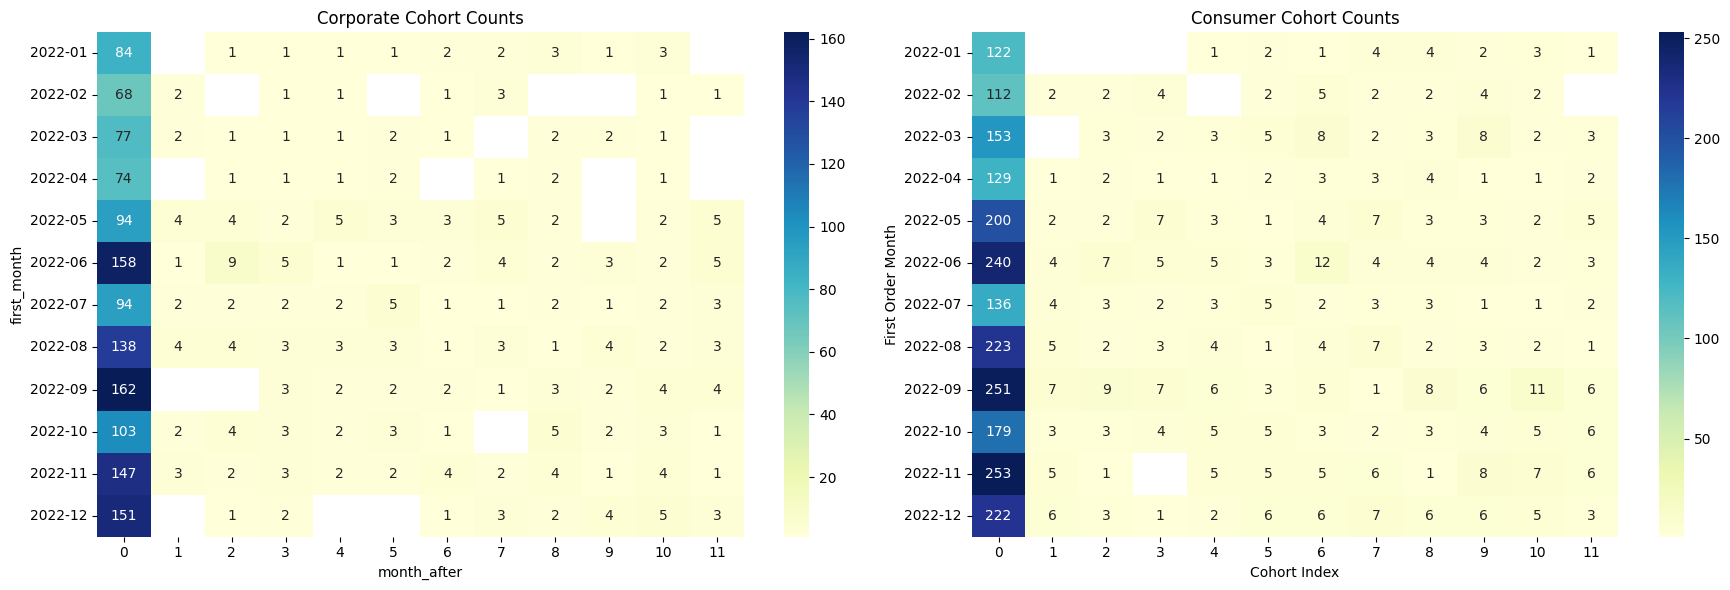

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

sns.heatmap(corp_counts,
            annot=True,
            cmap='YlGnBu',
            fmt='g',
            ax=axes[0])
axes[0].set_title('Corporate Cohort Counts')

sns.heatmap(cons_counts,
            annot=True,
            cmap='YlGnBu',
            fmt='g',
            ax=axes[1])
axes[1].set_title('Consumer Cohort Counts')

plt.xlabel('Cohort Index')
plt.ylabel('First Order Month')
plt.tight_layout()
plt.show()

In [ ]:
df_cohort_segmentpivot = df_cohort_merge.groupby(['Segment', 'first_month', 'month_after'], observed=True)['CustomerID'].nunique().reset_index().pivot_table(
    index=['Segment', 'first_month'],
    columns='month_after',
    values='CustomerID')

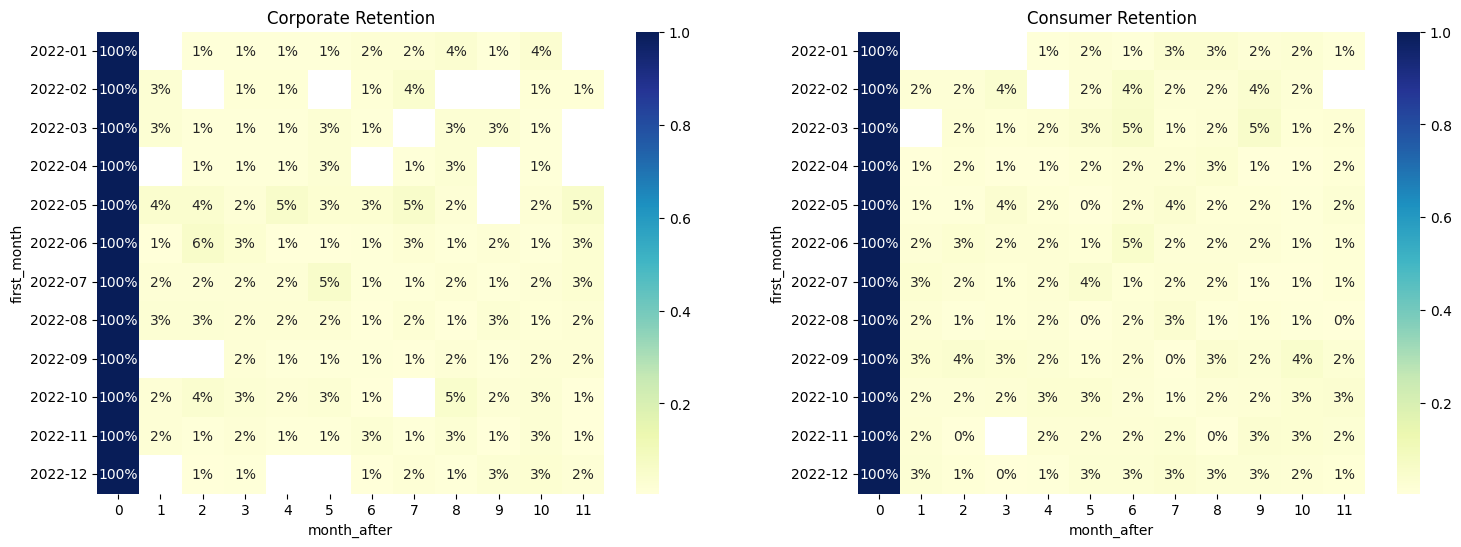

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Corporate Retention
sns.heatmap(corp,
            annot=True,
            cmap='YlGnBu',
            fmt='.0%',
            ax=axes[0])
axes[0].set_title('Corporate Retention')

# Consumer Retention
sns.heatmap(cons,
            annot=True,
            cmap='YlGnBu',
            fmt='.0%',
            ax=axes[1])
axes[1].set_title('Consumer Retention')

plt.show()

## Retention Rate Comparison: Corporate vs. Consumer Cohorts (2022 Data)

From our cohort analysis, we observe distinct patterns in customer retention between the Corporate and Consumer segments:

*   **Consumer Cohort**: This segment generally shows a **more distributed and slightly more continuous** retention pattern, though retention rates remain low. For example, the average 6-month retention for Consumers is around **2.25%**, and 11-month retention is **2.12%**. The heatmap for Consumers has fewer empty cells, indicating that returning customers are more consistently observed across different cohorts.

*   **Corporate Cohort**: This segment exhibits **less continuous retention**, with many months showing 0% retention (NaNs on the heatmap). The average 6-month retention for Corporates is approximately **1.83%**, and 11-month retention is **1.81%**. This suggests that Corporate customers tend to either be very short-term engaged or do not return after the initial period.

### **Cohort Analysis Insights:**

Cohort analysis reveals that:

1.  **Consumers** tend to have a **steadier, albeit small, long-term engagement**. This implies that strategies focused on continuous, gentle customer nurturing might be effective for this group.
2.  **Corporates** show **less sustainable engagement** over time. This might necessitate stronger re-engagement campaigns immediately after the first month, or a strategic focus on maximizing transaction value during their initial purchases.

While neither group displays exceptionally high retention rates, the cohort analysis clearly highlights the difference in the "presence" of returning customers across cohorts, offering valuable insights into their distinct behaviors.

# **6. Insight Generation - Annual Income Group**

###Task 3:Find Insights: Which Annual Income customer group yields the most sustainable profit?

In [ ]:
# Tính trung bình AnnualIncome theo first_month và month_after
income_trend = df_cohort_merge.groupby(['first_month', 'month_after']).agg(
    avg_annual_income = ('AnnualIncome', 'mean'),
    num_customers = ('CustomerID', 'nunique')
).round(0)

# Chỉ lấy 12 cohort năm 2022 và tối đa 12 tháng sau
income_trend = income_trend.loc[(slice('2022-01', '2022-12'), slice(0, 11)), :]

income_trend

avg_annual_income  num_customers
first_month month_after                                  
2022-01     0                      58438.0            252
            1                      70000.0              1
            2                      60000.0              1
            3                      40000.0              4
            4                      44545.0              4
...                                    ...            ...
2022-12     7                      64444.0             11
            8                      52273.0             11
            9                      50909.0             12
            10                     45000.0             13
            11                     62000.0              7

[144 rows x 2 columns]

In [ ]:
# Pivot để xem trend theo tháng sau
income_pivot = income_trend.reset_index().pivot_table(
    index='first_month',
    columns='month_after',
    values='avg_annual_income'
).round(0)
income_pivot

month_after,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2022-01,58438.0,70000.0,60000.0,40000.0,44545.0,58571.0,40000.0,31176.0,35000.0,23333.0,70000.0,60000.0
2022-02,57579.0,53333.0,66667.0,44545.0,40000.0,67778.0,46429.0,28571.0,74000.0,52000.0,58889.0,30000.0
2022-03,57458.0,75000.0,76154.0,87000.0,92857.0,42727.0,42500.0,55000.0,54286.0,52308.0,67000.0,66000.0
2022-04,56224.0,60000.0,66364.0,72500.0,67500.0,46667.0,35000.0,37857.0,45000.0,30000.0,84000.0,80000.0
2022-05,59762.0,46875.0,64375.0,54762.0,71250.0,30909.0,40833.0,52308.0,56250.0,73333.0,68000.0,35200.0
2022-06,56538.0,61111.0,54848.0,78889.0,67000.0,64545.0,69000.0,71765.0,67143.0,52500.0,61000.0,55217.0
2022-07,53439.0,56667.0,51538.0,37143.0,61667.0,65556.0,56250.0,30000.0,54375.0,62000.0,34000.0,53333.0
2022-08,59674.0,45000.0,52609.0,47000.0,57333.0,63333.0,56429.0,54286.0,69333.0,45714.0,29375.0,52857.0
2022-09,53891.0,64762.0,55000.0,39143.0,53333.0,57692.0,43333.0,57647.0,74390.0,58000.0,50976.0,48077.0


In [ ]:
trend_list = []
for cohort in income_pivot.index:
    incomes = income_pivot.loc[cohort].values.astype(float)
    months = np.arange(len(incomes))

    # Tính độ dốc (slope)
    slope = np.polyfit(months, incomes, 1)[0]
    trend_list.append({
        'Cohort': cohort,
        'Slope': round(slope, 2),
        'Avg_Income_all': round(incomes.mean(), 0),
        'Income_month0': round(incomes[0], 0),
        'Income_month11': round(incomes[-1], 0) if len(incomes) > 1 else None
    })

trend_df = pd.DataFrame(trend_list).set_index('Cohort')
trend_df

,Slope,Avg_Income_all,Income_month0,Income_month11
Cohort,,,,
2022-01,-1129.95,49255.0,58438.0,60000.0
2022-02,-924.46,51649.0,57579.0,30000.0
2022-03,-1476.67,64024.0,57458.0,66000.0
2022-04,-52.83,56759.0,56224.0,80000.0
2022-05,-198.65,54488.0,59762.0,35200.0
2022-06,-251.56,63296.0,56538.0,55217.0
2022-07,-524.76,51331.0,53439.0,53333.0
2022-08,-588.31,52745.0,59674.0,52857.0
2022-09,27.24,54687.0,53891.0,48077.0


In [ ]:
# Xếp theo Slope giảm dần (càng cao càng tốt)
trend_df.sort_values(by='Slope', ascending=False)

,Slope,Avg_Income_all,Income_month0,Income_month11
Cohort,,,,
2022-10,1640.35,61897.0,59870.0,66154.0
2022-12,1275.66,52494.0,55980.0,62000.0
2022-11,643.23,62412.0,62747.0,60000.0
2022-09,27.24,54687.0,53891.0,48077.0
2022-04,-52.83,56759.0,56224.0,80000.0
2022-05,-198.65,54488.0,59762.0,35200.0
2022-06,-251.56,63296.0,56538.0,55217.0
2022-07,-524.76,51331.0,53439.0,53333.0
2022-08,-588.31,52745.0,59674.0,52857.0


**Key Insight:**

The most sustainable customer cohort by Annual Income is 2022-10.

- Strongest upward trend (Slope = +1,640 — highest among all cohorts)
Average income increased from 59,870 (Month 0) to 66,154 (Month 11)

Cohorts acquired in late 2022 also performed well:

- 2022-12: Slope +1,276
- 2022-11: Slope +643

In contrast, early 2022 cohorts showed sharp declines (e.g., 2022-03: Slope -1,477).
Recommendation:
Prioritize marketing and retention efforts on customers acquired in Q4 2022 (Oct–Dec) as they deliver the most stable and growing income over time.